# ***Crear dataset sintetico***

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2000  # número de vehículos

df = pd.DataFrame({
    "vehicle_age": np.random.randint(1, 15, n),
    "km_driven": np.random.randint(5000, 300000, n),
    "engine_temp": np.random.normal(90, 15, n),
    "vibration_level": np.random.normal(1.0, 0.3, n),
    "battery_health": np.random.uniform(50, 100, n),
    "last_service_km": np.random.randint(0, 50000, n),
    "maintenance_delay_days": np.random.randint(0, 120, n),
    "driving_hours_day": np.random.uniform(1, 12, n),
    "load_weight": np.random.uniform(200, 2000, n)
})

## ***Simular fallo***

In [ ]:
df["failure_risk"] = (
    (df["vehicle_age"] > 8).astype(int) +
    (df["km_driven"] > 150000).astype(int) +
    (df["engine_temp"] > 100).astype(int) +
    (df["vibration_level"] > 1.3).astype(int) +
    (df["battery_health"] < 65).astype(int) +
    (df["maintenance_delay_days"] > 60).astype(int)
)

df["failure_risk"] = (df["failure_risk"] > 2).astype(int)

# ***Analisis exploratorio***

In [ ]:
df.head()

,vehicle_age,km_driven,engine_temp,vibration_level,battery_health,last_service_km,maintenance_delay_days,driving_hours_day,load_weight,failure_risk
0,7,139092,115.253197,1.077229,54.378779,13117,26,10.215332,1586.788055,0
1,4,91988,82.093179,0.708772,90.283769,11231,112,11.568141,1678.295319,0
2,13,50648,60.998383,1.240841,83.459183,29751,16,1.449758,1457.758620,0
3,11,130991,115.331909,1.868956,86.622073,7440,47,1.858351,1445.923520,1
4,8,7396,103.893665,1.264152,71.610659,19911,20,10.731970,1111.230680,0


In [ ]:
df.describe()

,vehicle_age,km_driven,engine_temp,vibration_level,battery_health,last_service_km,maintenance_delay_days,driving_hours_day,load_weight,failure_risk
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,7.425000,155507.317500,89.955336,1.005921,74.924153,24507.178000,58.357000,6.502148,1103.382203,0.372500
std,4.065051,84197.400707,15.013497,0.299485,14.507802,14289.465448,34.942024,3.149145,513.918221,0.483591
min,1.000000,5138.000000,39.197794,0.011124,50.056574,5.000000,0.000000,1.001305,206.071298,0.000000
25%,4.000000,82930.500000,79.624294,0.804793,62.553419,12195.500000,28.000000,3.786859,666.255306,0.000000
50%,7.000000,157313.500000,89.994559,1.005212,74.992073,23708.000000,58.000000,6.566890,1093.179966,0.000000
75%,11.000000,229136.750000,100.573415,1.209840,87.642909,37123.250000,88.000000,9.169097,1528.252896,1.000000
max,14.000000,299923.000000,133.811288,2.215765,99.987064,49986.000000,119.000000,11.997984,1999.806800,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vehicle_age             2000 non-null   int64  
 1   km_driven               2000 non-null   int64  
 2   engine_temp             2000 non-null   float64
 3   vibration_level         2000 non-null   float64
 4   battery_health          2000 non-null   float64
 5   last_service_km         2000 non-null   int64  
 6   maintenance_delay_days  2000 non-null   int64  
 7   driving_hours_day       2000 non-null   float64
 8   load_weight             2000 non-null   float64
 9   failure_risk            2000 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 156.4 KB


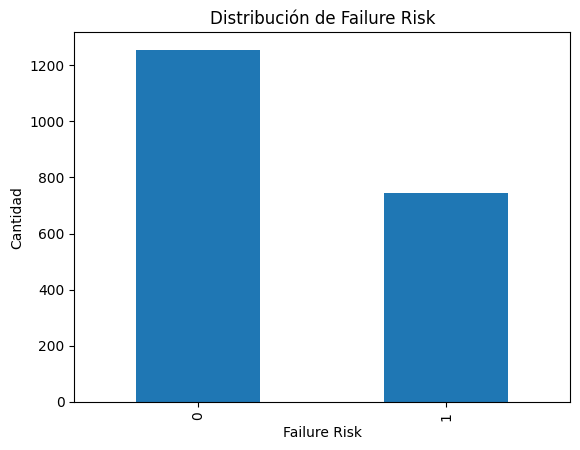

In [ ]:
import matplotlib.pyplot as plt

df["failure_risk"].value_counts().plot(kind="bar")

plt.title("Distribución de Failure Risk")
plt.xlabel("Failure Risk")
plt.ylabel("Cantidad")
plt.show()

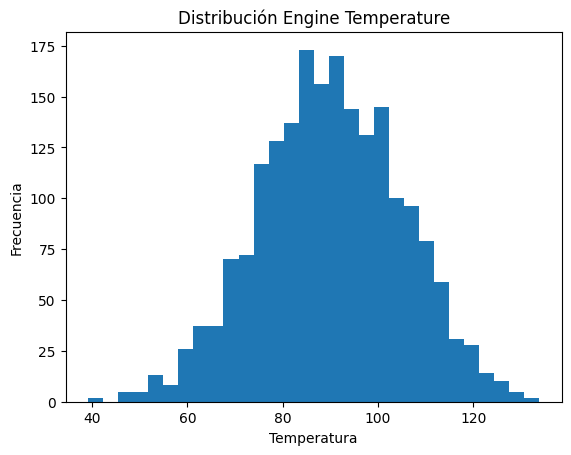

In [ ]:
plt.hist(df["engine_temp"], bins=30)

plt.title("Distribución Engine Temperature")
plt.xlabel("Temperatura")
plt.ylabel("Frecuencia")

plt.show()

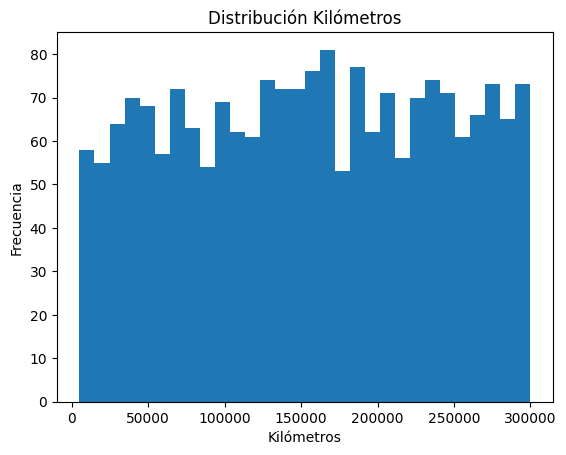

In [ ]:
plt.hist(df["km_driven"], bins=30)

plt.title("Distribución Kilómetros")
plt.xlabel("Kilómetros")
plt.ylabel("Frecuencia")

plt.show()

# ***Correlacion***

In [ ]:
corr = df.corr()

corr["failure_risk"].sort_values(ascending=False)

,failure_risk
failure_risk,1.000000
vehicle_age,0.307499
maintenance_delay_days,0.297647
km_driven,0.291440
engine_temp,0.252436
vibration_level,0.180035
last_service_km,0.019631
load_weight,0.019048
driving_hours_day,0.011814
battery_health,-0.295072


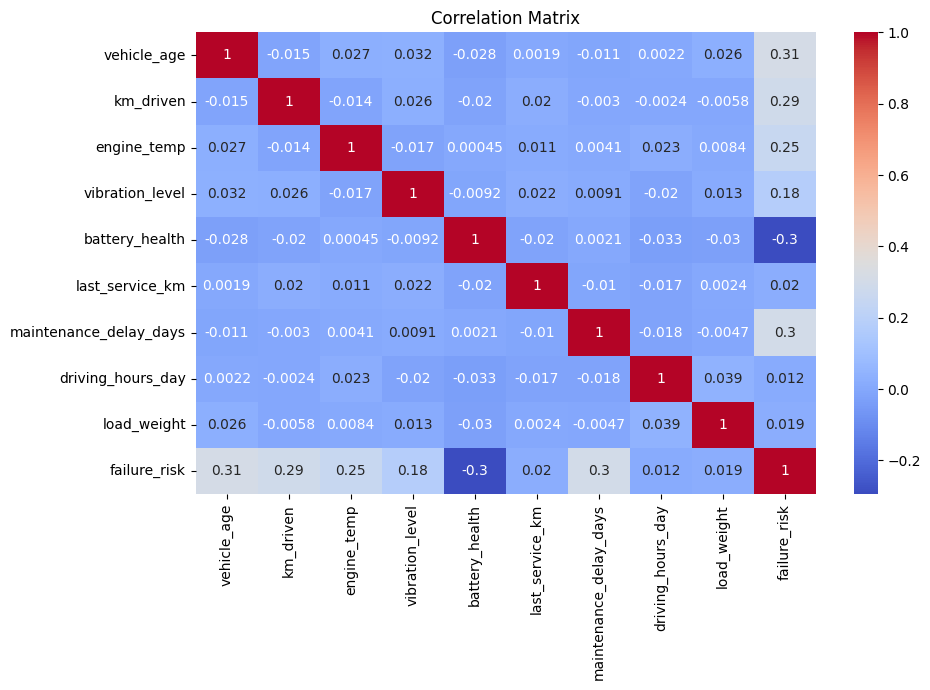

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# ***Crear modelo***

In [ ]:
X = df.drop("failure_risk", axis=1)

y = df["failure_risk"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
rf = RandomForestClassifier(random_state=42)

In [ ]:
param_grid = {
    "n_estimators": [4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30],
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1750 candidates, totalling 8750 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 9, None],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'min_samples_split': [2, 4, 6, 8, 10],
                         'n_estimators': [4, 6, 8, 10, 12, 14, 16, 18, 20, 22,
                                          24, 26, 28, 30]},
             scoring='f1', verbose=1)

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 22}


# ***Predicciones***

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9575

Classification Report:

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       225
           1       1.00      0.90      0.95       175

    accuracy                           0.96       400
   macro avg       0.96      0.95      0.96       400
weighted avg       0.96      0.96      0.96       400



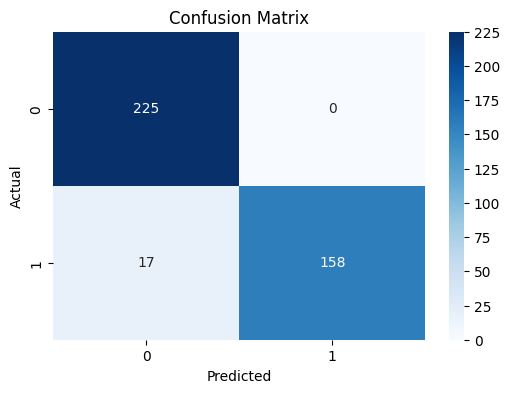

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ***Resultados***

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                  Feature  Importance
6  maintenance_delay_days    0.187373
4          battery_health    0.166645
1               km_driven    0.164923
0             vehicle_age    0.158425
2             engine_temp    0.153904
3         vibration_level    0.103083
8             load_weight    0.026165
5         last_service_km    0.020404
7       driving_hours_day    0.019078


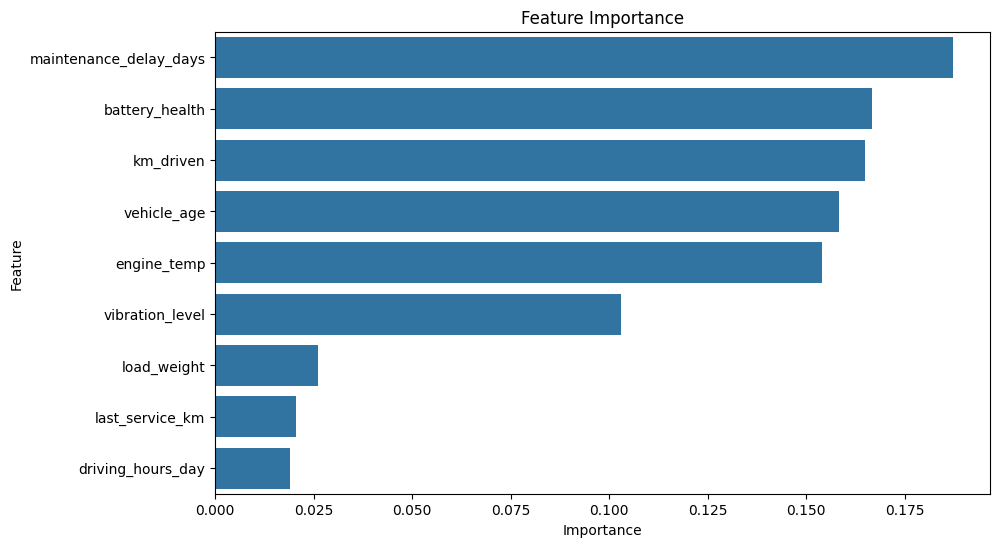

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()